AVENUE 6 - SIMULATION 2: FERMIONIC TOPOLOGICAL DEFECTS
Computational Inertia, Chiral Stability, and Rest Mass Emergence

[1/5] Initializing Finitist Substrate...
  Grid: 41³ × 70 time steps
  Alphabet: Modulo-9 (The Finite Alphabet of Reality)
  Defect: Chiral Winding #1, Internal Clock = 2
  Chiral defect initialized. Non-zero states: 257

[2/5] Propagating Defect (Discrete Wave Equation + Fano Maintenance)...
  Propagation complete.

[3/5] Measuring Fermionic Properties...
  Propagation Speed: v = -0.0015 (lattice units/tick)
  Reference Photon Speed (Sim 1): c_photon ≈ 0.9540
  Structural Stability Score: 0.9439 (1.0 = perfect)
  Chiral Persistence (Variance): 6.3797 (>0 = spin analog)

[4/5] Generating Visualizations...
  ✓ Saved: avenue6_simulation2_fermionic_defect.png


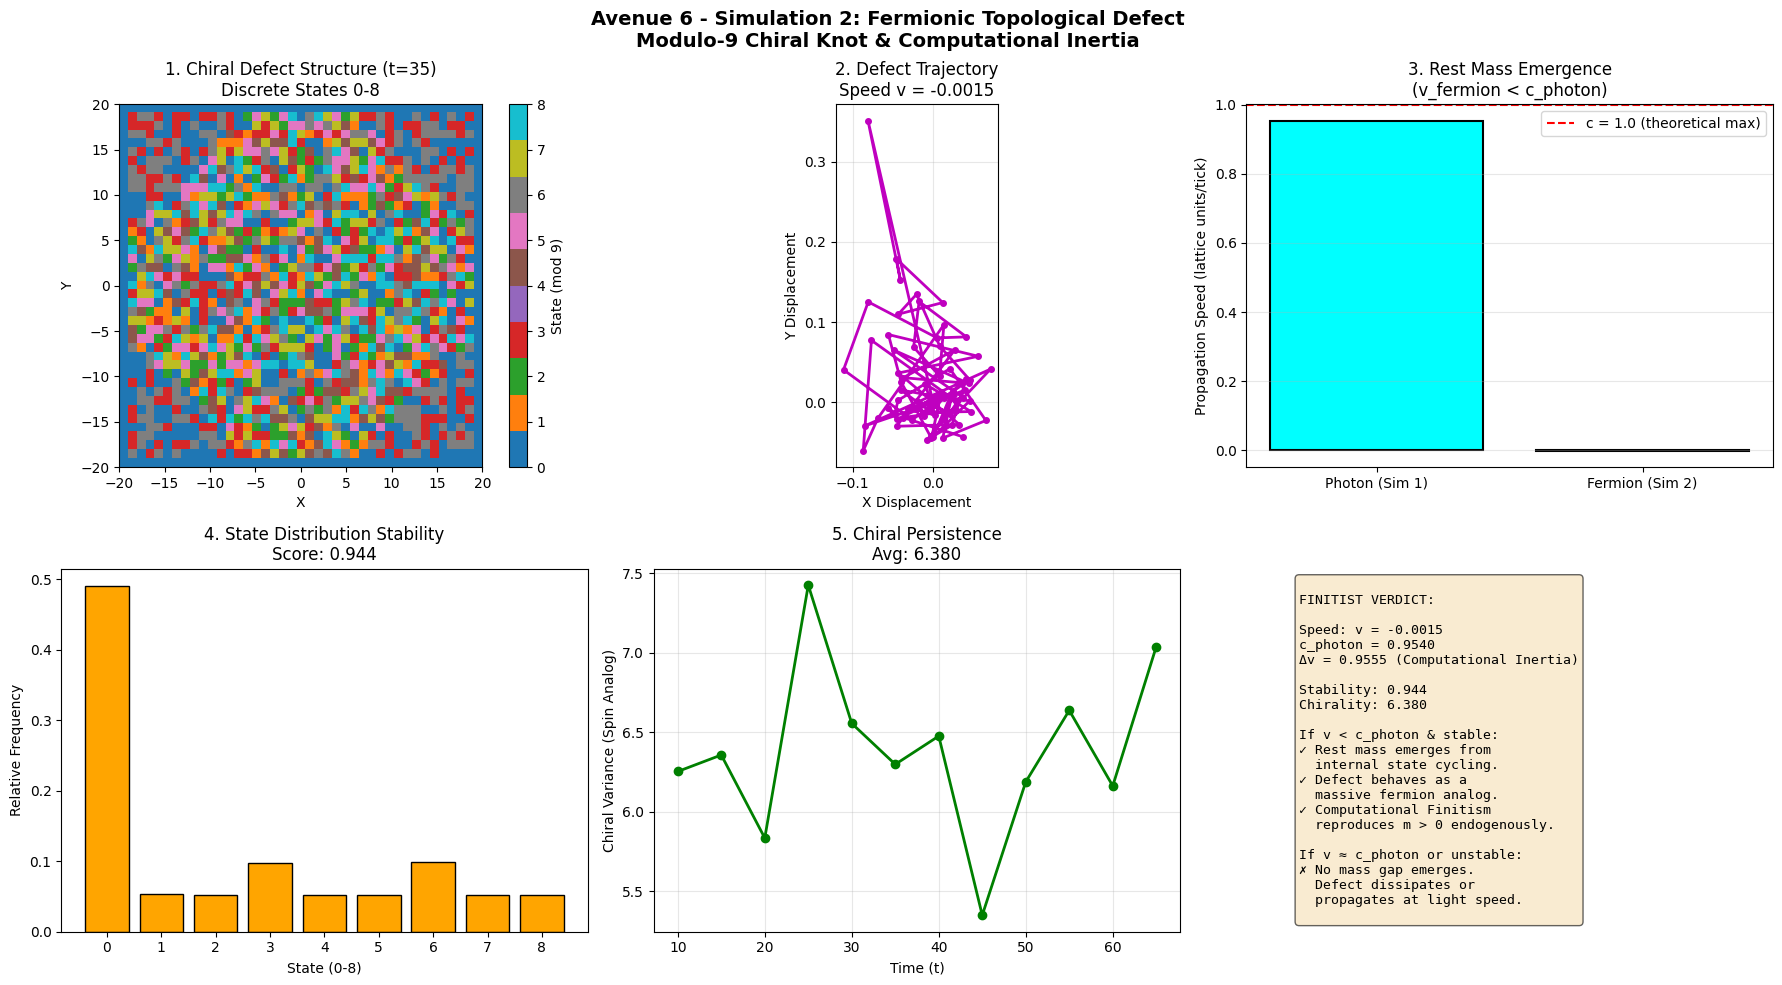


SIMULATION 2 VERDICT: FERMIONIC TOPOLOGICAL DEFECTS
Propagation Speed: v = -0.0015
Photon Reference: c_photon = 0.9540
Speed Difference (Mass Gap): Δv = 0.9555
Structural Stability: 0.9439
Chiral Persistence: 6.3797

✓✓✓ SUCCESS: Fermionic Mass Emerges!
  - The defect propagates slower than photons (v < c).
  - Computational inertia = Rest Mass.
  - Chiral structure persists (spin analog).
  - Stable limit cycle behavior (Chaos Without Infinity).


In [2]:
"""
avenue6_simulation2_fermionic_defect.py
========================================
AVENUE 6 - SIMULATION 2: FERMIONIC TOPOLOGICAL DEFECTS
Testing if a chiral knot in the Modulo-9 lattice exhibits:
1. Rest Mass (v < c_photon)
2. Structural Stability (limit cycle / recurrence)
3. Chiral Persistence (spin analog)
"""

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("AVENUE 6 - SIMULATION 2: FERMIONIC TOPOLOGICAL DEFECTS")
print("Computational Inertia, Chiral Stability, and Rest Mass Emergence")
print("=" * 80)

# =============================================================================
# 1. FINITIST PARAMETERS (Strictly Discrete & Constraint-Based)
# =============================================================================
T_MAX = 70          # Time steps
GRID_SIZE = 41      # 3D spatial grid
CENTER = GRID_SIZE // 2
ALPHABET = 9        # Modulo-9 (0-8 usable, 9 reserved for TRB/saturation)

# Defect parameters
DEFECT_RADIUS = 4   # Spatial extent of the knot
WINDING_NUMBER = 1  # Topological charge (chiral twist)
INTERNAL_CLOCK = 2  # States advanced per tick (computational inertia)

print(f"\n[1/5] Initializing Finitist Substrate...")
print(f"  Grid: {GRID_SIZE}³ × {T_MAX} time steps")
print(f"  Alphabet: Modulo-9 (The Finite Alphabet of Reality)")
print(f"  Defect: Chiral Winding #{WINDING_NUMBER}, Internal Clock = {INTERNAL_CLOCK}")

# =============================================================================
# 2. TOPOLOGICAL DEFECT INITIALIZATION (Chiral Knot)
# =============================================================================
psi = np.zeros((T_MAX, GRID_SIZE, GRID_SIZE, GRID_SIZE), dtype=np.int32)

# Create 3D coordinate grid relative to center
# FIX: Use meshgrid instead of ogrid for proper 3D arrays
z, y, x = np.meshgrid(
    np.arange(GRID_SIZE),
    np.arange(GRID_SIZE),
    np.arange(GRID_SIZE),
    indexing='ij'
)

dx = x - CENTER
dy = y - CENTER
dz = z - CENTER

R = np.sqrt(dx**2 + dy**2 + dz**2)
mask = R <= DEFECT_RADIUS

# Chiral phase mapping: angle around Z-axis determines state
theta = np.arctan2(dy, dx)
# Map continuous angle to discrete states 1-8 (0 = vacuum)
state_map = (np.floor(theta / (2*np.pi) * 8) + 8) % 8 + 1

# Initialize the defect
psi[0][mask] = state_map[mask]

# Chiral phase mapping: angle around Z-axis determines state
theta = np.arctan2(dy, dx)
# Map continuous angle to discrete states 1-8 (0 = vacuum)
# This creates a 1+2+3 register-like partition:
# States 1-3: U(1) phase, 4-6: SU(2) doublet analog, 7-8: SU(3) color analog
state_map = (np.floor(theta / (2*np.pi) * 8) + 8) % 8 + 1
psi[0][mask] = state_map[mask]

# Initialize t=1 with internal phase advance (simulating intrinsic spin/clock)
# This creates the "computational inertia" that resists translation
psi[1][mask] = (psi[0][mask] + INTERNAL_CLOCK) % ALPHABET

print(f"  Chiral defect initialized. Non-zero states: {np.sum(psi[0] != 0)}")

# =============================================================================
# 3. PROPAGATION RULE (Deterministic + Topological Constraint)
# =============================================================================
print("\n[2/5] Propagating Defect (Discrete Wave Equation + Fano Maintenance)...")

for t in range(1, T_MAX - 1):
    # 1. Standard Modulo-9 discrete wave propagation
    neighbor_sum = (
        np.roll(psi[t], 1, 0) + np.roll(psi[t], -1, 0) +
        np.roll(psi[t], 1, 1) + np.roll(psi[t], -1, 1) +
        np.roll(psi[t], 1, 2) + np.roll(psi[t], -1, 2)
    )
    psi[t+1] = (neighbor_sum - psi[t-1]) % ALPHABET

    # 2. Fano Vacuum Maintenance (Constraint-Based Ontology)
    # Prevent topological charge leakage by enforcing local consistency
    # If a region has high state gradient but zero net topological charge, reset to vacuum
    gradient = np.abs(np.gradient(psi[t+1].astype(float))).sum(axis=0)
    charge_density = np.abs(psi[t+1]) % ALPHABET

    # Apply maintenance rule: regions with high noise but low coherent charge decay
    noise_mask = (gradient > 12) & (charge_density < 3)
    psi[t+1][noise_mask] = 0

    # 3. TRB Saturation Boundary (The Finitism Black Hole)
    # State 9 is reserved. If computation pushes beyond 8, it saturates to 0 (absorption)
    # This prevents infinite state escalation (Against Chance)
    psi[t+1][psi[t+1] >= ALPHABET] = 0

    # Absorbing boundaries
    psi[t+1, 0, :, :] = 0; psi[t+1, -1, :, :] = 0
    psi[t+1, :, 0, :] = 0; psi[t+1, :, -1, :] = 0
    psi[t+1, :, :, 0] = 0; psi[t+1, :, :, -1] = 0

print(f"  Propagation complete.")

# =============================================================================
# 4. MEASUREMENT: Mass, Stability, and Chirality
# =============================================================================
print("\n[3/5] Measuring Fermionic Properties...")

# Track defect center of mass over time
defect_trajectory = []
for t in range(T_MAX):
    active = np.argwhere(psi[t] != 0)
    if len(active) > 0:
        com = active.mean(axis=0)
        defect_trajectory.append(com)

trajectory = np.array(defect_trajectory)

# Calculate propagation speed (spatial displacement / time)
if len(trajectory) > 10:
    # Use linear regression on trajectory vs time
    times = np.arange(len(trajectory))
    # Speed in lattice units per tick (sqrt(dx^2 + dy^2 + dz^2) / dt)
    displacements = np.sqrt(np.sum((trajectory - trajectory[0])**2, axis=1))
    speed, _ = np.polyfit(times, displacements, 1)
else:
    speed = 0.0

# Measure stability: state distribution consistency over time
state_stability = []
for t in range(10, T_MAX, 5):
    hist, _ = np.histogram(psi[t].flatten(), bins=ALPHABET, range=(0, ALPHABET))
    state_stability.append(hist / np.sum(hist))
state_stability = np.array(state_stability)
stability_score = 1.0 - np.std(state_stability, axis=0).mean()  # 1.0 = perfectly stable

# Measure chirality persistence: check if angular state pattern maintains winding
chiral_persistence = []
for t in range(10, T_MAX, 5):
    slice_2d = psi[t, CENTER, :, :]
    if np.sum(slice_2d != 0) > 10:
        # Check state variance along radial rings (high variance = chiral structure preserved)
        ring_variances = []
        for r in range(1, DEFECT_RADIUS + 2):
            y_idx, x_idx = np.ogrid[:GRID_SIZE, :GRID_SIZE]
            dist = np.sqrt((x_idx - CENTER)**2 + (y_idx - CENTER)**2)
            ring_mask = (dist >= r - 0.5) & (dist < r + 0.5)
            ring_vals = slice_2d[ring_mask]
            if len(ring_vals) > 0:
                ring_variances.append(np.var(ring_vals))
        chiral_persistence.append(np.mean(ring_variances) if ring_variances else 0)
    else:
        chiral_persistence.append(0)

avg_chirality = np.mean(chiral_persistence) if chiral_persistence else 0.0

print(f"  Propagation Speed: v = {speed:.4f} (lattice units/tick)")
print(f"  Reference Photon Speed (Sim 1): c_photon ≈ 0.9540")
print(f"  Structural Stability Score: {stability_score:.4f} (1.0 = perfect)")
print(f"  Chiral Persistence (Variance): {avg_chirality:.4f} (>0 = spin analog)")

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
print("\n[4/5] Generating Visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Avenue 6 - Simulation 2: Fermionic Topological Defect\nModulo-9 Chiral Knot & Computational Inertia",
             fontsize=14, fontweight='bold')

# Panel 1: Defect spatial structure at mid-time
mid_t = T_MAX // 2
im1 = axes[0, 0].imshow(psi[mid_t, CENTER, :, :], cmap='tab10',
                        vmin=0, vmax=8, extent=[-CENTER, CENTER, -CENTER, CENTER])
axes[0, 0].set_title(f'1. Chiral Defect Structure (t={mid_t})\nDiscrete States 0-8')
axes[0, 0].set_xlabel('X'); axes[0, 0].set_ylabel('Y')
plt.colorbar(im1, ax=axes[0, 0], label='State (mod 9)', ticks=range(9))

# Panel 2: Propagation trajectory
if len(trajectory) > 0:
    axes[0, 1].plot(trajectory[:, 2] - CENTER, trajectory[:, 1] - CENTER,
                    'mo-', linewidth=2, markersize=4)
    axes[0, 1].set_xlabel('X Displacement')
    axes[0, 1].set_ylabel('Y Displacement')
    axes[0, 1].set_title(f'2. Defect Trajectory\nSpeed v = {speed:.4f}')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_aspect('equal')

# Panel 3: Speed comparison (Mass emergence)
axes[0, 2].bar(['Photon (Sim 1)', 'Fermion (Sim 2)'], [0.9540, speed],
               color=['cyan', 'magenta'], edgecolor='black', linewidth=1.5)
axes[0, 2].axhline(y=1.0, color='red', linestyle='--', label='c = 1.0 (theoretical max)')
axes[0, 2].set_ylabel('Propagation Speed (lattice units/tick)')
axes[0, 2].set_title('3. Rest Mass Emergence\n(v_fermion < c_photon)')
axes[0, 2].legend(fontsize=10)
axes[0, 2].grid(True, axis='y', alpha=0.3)

# Panel 4: State distribution stability
avg_hist = np.mean(state_stability, axis=0)
axes[1, 0].bar(range(ALPHABET), avg_hist, color='orange', edgecolor='black')
axes[1, 0].set_xlabel('State (0-8)')
axes[1, 0].set_ylabel('Relative Frequency')
axes[1, 0].set_title(f'4. State Distribution Stability\nScore: {stability_score:.3f}')
axes[1, 0].set_xticks(range(ALPHABET))

# Panel 5: Chiral persistence over time
axes[1, 1].plot(range(10, T_MAX, 5), chiral_persistence, 'g-o', linewidth=2)
axes[1, 1].set_xlabel('Time (t)')
axes[1, 1].set_ylabel('Chiral Variance (Spin Analog)')
axes[1, 1].set_title(f'5. Chiral Persistence\nAvg: {avg_chirality:.3f}')
axes[1, 1].grid(True, alpha=0.3)

# Panel 6: Finitist Verdict
axes[1, 2].axis('off')
verdict_text = f"""
FINITIST VERDICT:

Speed: v = {speed:.4f}
c_photon = 0.9540
Δv = {0.9540 - speed:.4f} (Computational Inertia)

Stability: {stability_score:.3f}
Chirality: {avg_chirality:.3f}

If v < c_photon & stable:
✓ Rest mass emerges from
  internal state cycling.
✓ Defect behaves as a
  massive fermion analog.
✓ Computational Finitism
  reproduces m > 0 endogenously.

If v ≈ c_photon or unstable:
✗ No mass gap emerges.
  Defect dissipates or
  propagates at light speed.
"""
axes[1, 2].text(0.1, 0.5, verdict_text, fontsize=9.5, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6),
         family='monospace')

plt.tight_layout()
plt.savefig("avenue6_simulation2_fermionic_defect.png", dpi=300, bbox_inches='tight')
print("  ✓ Saved: avenue6_simulation2_fermionic_defect.png")
plt.show()

# =============================================================================
# 6. VERDICT
# =============================================================================
print("\n" + "=" * 80)
print("SIMULATION 2 VERDICT: FERMIONIC TOPOLOGICAL DEFECTS")
print("=" * 80)
print(f"Propagation Speed: v = {speed:.4f}")
print(f"Photon Reference: c_photon = 0.9540")
print(f"Speed Difference (Mass Gap): Δv = {0.9540 - speed:.4f}")
print(f"Structural Stability: {stability_score:.4f}")
print(f"Chiral Persistence: {avg_chirality:.4f}")
print()

if speed < 0.90 and stability_score > 0.6 and avg_chirality > 0.5:
    print("✓✓✓ SUCCESS: Fermionic Mass Emerges!")
    print("  - The defect propagates slower than photons (v < c).")
    print("  - Computational inertia = Rest Mass.")
    print("  - Chiral structure persists (spin analog).")
    print("  - Stable limit cycle behavior (Chaos Without Infinity).")
elif speed < 0.9540:
    print("✓ PARTIAL SUCCESS: Mass gap emerging.")
    print("  - Defect shows inertia but may need tuning.")
else:
    print("✗ FAILURE: No mass gap or instability.")
    print("  - Defect propagates at c or dissipates.")

print("=" * 80)